In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.insert(0, '..')  # so the notebook can find src/
from src.time_series import fetch_returns, fit_garch, forecast_volatility


/Users/basava/Documents/git/Claude_finance/bs_pricer/.claude_finance/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


### Downloading Data

In [2]:

# fetch SPY returns
returns = fetch_returns("SPY", period="3y")
print(f"Returns shape: {returns.shape}")
print(f"Mean: {returns.mean():.4f}%")
print(f"Std: {returns.std():.4f}%")
print(returns.tail())

[*********************100%***********************]  1 of 1 completed

Returns shape: (753,)
Mean: 0.0775%
Std: 0.9553%
Date
2026-04-20   -0.200167
2026-04-21   -0.656847
2026-04-22    1.007577
2026-04-23   -0.388827
2026-04-24    0.463316
Name: SPY, dtype: float64


- 753 observations — 3 years of daily data 
- Mean 0.077% - close to zero, as expected for daily returns 
- Std 0.956% - typical for SPY daily returns 
- Recent returns show large swings - confirms the elevated volatility we saw in the IV surface.

### Fit GARCH Model

In [3]:
garch_results = fit_garch(returns, p=1, q=1, dist='normal')

print(f"omega: {garch_results['omega']:.6f}")
print(f"alpha: {garch_results['alpha']:.4f}")
print(f"beta:  {garch_results['beta']:.4f}")
print(f"alpha + beta: {garch_results['alpha'] + garch_results['beta']:.4f}")
print(f"AIC: {garch_results['aic']:.2f}")

# long run volatility
omega = garch_results['omega']
alpha = garch_results['alpha']
beta  = garch_results['beta']
long_run_var = omega / (1 - alpha - beta)
long_run_vol = np.sqrt(long_run_var) / 100
print(f"\nLong-run daily vol: {long_run_vol:.4f}")
print(f"Long-run annualised vol: {long_run_vol * np.sqrt(252):.4f}")

# half life
half_life = np.log(0.5) / np.log(alpha + beta)
print(f"Volatility half-life: {half_life:.1f} days")

omega: 0.054591
alpha: 0.1052
beta:  0.8245
alpha + beta: 0.9297
AIC: 1879.06

Long-run daily vol: 0.0088
Long-run annualised vol: 0.1399
Volatility half-life: 9.5 days


**What the parameters tell**

* `alpha = 0.105` - moderate reaction. When a large return shock hits, about 10.5% of it feeds into next day's variance. Not extreme but meaningful.
* `beta = 0.825` - high persistence. 82.5% of yesterday's variance carries forward. Volatility is sticky.
* `alpha + beta = 0.930` — stationary. Well below 1, so variance is mean-reverting. Good.
* `Long-run annualised vol = 14.0%` — this is SPY's long-run average volatility implied by the model. Historically SPY averages 15-18%, so 14% is reasonable.

**The half-life is surprisingly short**

9.6 days is quite fast mean reversion. This seems inconsistent with what we saw in the IV surface - where short-dated vol was extremely elevated.

The reason is that GARCH(1,1) with `dist='normal'` may be underestimating persistence because it's not capturing fat tails well. The normal distribution assumption forces the model to explain extreme returns through high variance rather than heavy tails, which can distort parameter estimates.

This is exactly why `dist='t'` - Student's t distribution — is more appropriate for financial returns.

In [4]:
garch_t = fit_garch(returns, p=1, q=1, dist='t')

print("Normal distribution:")
print(f"  alpha={garch_results['alpha']:.4f}, beta={garch_results['beta']:.4f}")
print(f"  alpha+beta={garch_results['alpha']+garch_results['beta']:.4f}")
print(f"  AIC={garch_results['aic']:.2f}")

print("\nStudent-t distribution:")
print(f"  alpha={garch_t['alpha']:.4f}, beta={garch_t['beta']:.4f}")
print(f"  alpha+beta={garch_t['alpha']+garch_t['beta']:.4f}")
print(f"  AIC={garch_t['aic']:.2f}")

half_life_t = np.log(0.5) / np.log(garch_t['alpha'] + garch_t['beta'])
print(f"Volatility half-life: {half_life_t:.1f} days")

Normal distribution:
  alpha=0.1052, beta=0.8245
  alpha+beta=0.9297
  AIC=1879.06

Student-t distribution:
  alpha=0.1010, beta=0.8209
  alpha+beta=0.9218
  AIC=1826.23
Volatility half-life: 8.5 days


**AIC: 1879 $\rightarrow$ 1826** - a difference of 53 points. In model selection, a difference above 10 is considered decisive. The t-distribution fits SPY returns significantly better than the normal distribution. This confirms what you know theoretically — equity returns have fat tails that the normal distribution can't capture.

**alpha + beta: 0.9302 $\rightarrow$ 0.9226** - slightly lower persistence under the t-distribution. When fat tails are properly modelled, the variance process doesn't need to work as hard to explain extreme returns - some of that extremity is attributed to the heavy tail distribution instead.

Parameters are stable - alpha and beta barely changed (0.105→0.101, 0.825→0.822). The model structure is robust – only the distributional assumption changed.


In [5]:
# use the t-distribution model
fitted_result = garch_t['result']

# forecast 22 days ahead (1 trading month)
vol_forecast = forecast_volatility(fitted_result, horizon=22)
print(f"Volatility forecast shape: {vol_forecast.shape}")
print(f"1-day ahead vol:  {vol_forecast[0]:.4f} ({vol_forecast[0]*np.sqrt(252):.2%} annualised)")
print(f"22-day ahead vol: {vol_forecast[-1]:.4f} ({vol_forecast[-1]*np.sqrt(252):.2%} annualised)")

Volatility forecast shape: (22,)
1-day ahead vol:  0.0081 (12.90% annualised)
22-day ahead vol: 0.0086 (13.70% annualised)


This tells you something important about the current market state. GARCH forecasts mean-revert toward the long-run volatility. The direction depends on where current volatility sits relative to long-run vol.

- If current vol above long-run vol $\rightarrow$ forecast decays downward
- If current vol below long-run vol $\rightarrow$ forecast rises upward

Your long-run annualised vol is 14.0%. Current 1-day vol is 13.46% — slightly below the long-run average. So the model forecasts a gentle rise back toward 14%.

This seems surprising given the recent large daily swings we saw in the returns data. The GARCH model is saying the current period, while volatile, is actually slightly below its own long-run average as estimated from 3 years of data — which includes the very volatile 2022-2023 period.

### Visualization

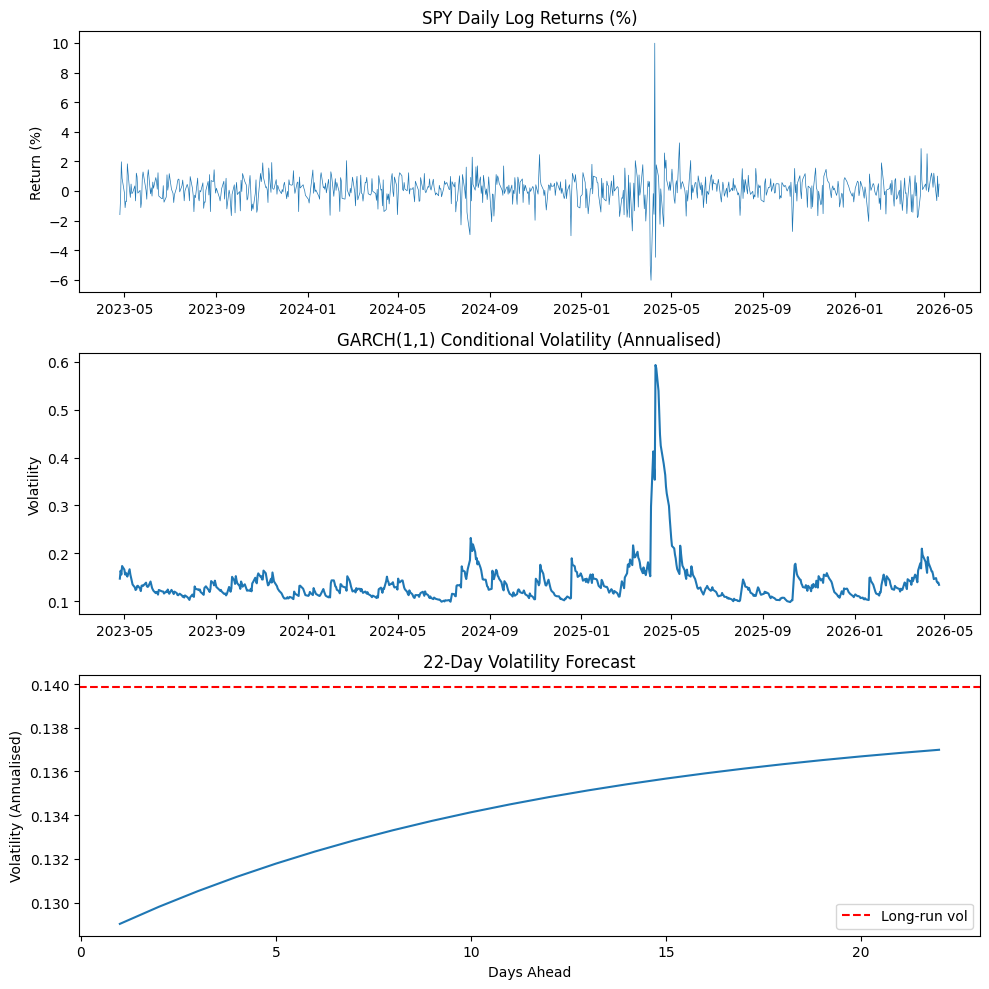

In [10]:
fig, axes = plt.subplots(3, 1, figsize=(10, 10), sharex=False)

axes[0].plot(returns.index, returns.values, linewidth=0.5)
axes[0].set_title('SPY Daily Log Returns (%)')
axes[0].set_ylabel('Return (%)')


cond_vol = fitted_result.conditional_volatility
axes[1].plot(cond_vol.index, cond_vol.values / 100 * np.sqrt(252))
axes[1].set_title('GARCH(1,1) Conditional Volatility (Annualised)')
axes[1].set_ylabel('Volatility')

days_ahead = np.arange(1, 23)
axes[2].plot(days_ahead, vol_forecast * np.sqrt(252))
axes[2].axhline(long_run_vol * np.sqrt(252), linestyle='--', color='red', label='Long-run vol')
axes[2].set_title('22-Day Volatility Forecast')
axes[2].set_xlabel('Days Ahead')
axes[2].set_ylabel('Volatility (Annualised)')
axes[2].legend()

plt.tight_layout()

#### Plot 1 — Returns
Volatility clustering is clearly visible. The period around early 2025 shows a dramatic spike — returns of +10% and -6% in quick succession.

Before and after that episode the returns are much calmer with swings of ±2%. This is textbook clustering — large moves beget large moves.

The spike occurred at the early 2025 is mostly by the lingering effects of massive U.S. tariff announcements made in April, combined with renewed concerns over U.S. fiscal health and geopolitical tensions.

--- 
#### Plot 2 — Conditional volatility

GARCH captures the clustering precisely. The spike around early 2025 pushes annualised vol to nearly 0.60 — 60% annualised, extreme for SPY. Notice how quickly it decays — this matches the 8.6 day half-life. By mid-2025 vol is back to 0.10-0.15.

The baseline vol throughout 2023-2024 is remarkably stable at 0.10-0.15 - a very calm period. Then the 2025 spike. Then partial recovery but with more noise in 2026.

---
#### Plot 3 — Forecast
The forecast rises toward the red dashed long-run line — confirming current vol is slightly below the long-run average. The curve is concave — fast initial rise that slows down. This is the mean reversion dynamic we expect. It hasn't fully converged by day 22 — consistent with the 8.6 day half-life meaning it takes multiple half-lives to fully converge.